# 0. 들어가며 — 왜 트랜스포머인가

이번 학습노트에서는 **트랜스포머(Transformer)** 를 밑바닥부터 구현한다. 트랜스포머는 2017년 구글이 논문 "Attention is all you need"에서 제안한 모델로, RNN을 완전히 제거하고 **어텐션(Attention)만으로** 인코더-디코더 구조를 설계했다. 이후 등장하는 BERT, GPT 등 현대 NLP 모델은 전부 이 구조의 변형이므로, 트랜스포머를 부품 단위까지 이해하면 이후의 모델들은 "부품을 어떻게 재배치했는가"의 문제로 단순해진다.

## Seq2Seq + 어텐션 복습, 그리고 남은 문제

기존의 Seq2Seq는 인코더 RNN이 입력 문장 전체를 하나의 고정 크기 **컨텍스트 벡터**로 압축하고, 디코더 RNN이 이를 받아 출력 문장을 만들었다. 문장이 길어지면 하나의 벡터에 모든 정보를 욱여넣는 과정에서 정보 손실이 생겼고, 이를 보정하기 위해 **어텐션 메커니즘**이 도입되었다. 디코더가 매 시점마다 인코더의 전체 은닉 상태를 다시 참고하는 방식이다.

어텐션으로 보정을 해도 RNN 자체의 구조적 한계 두 가지는 남는다.

**첫째, 순차 계산의 병목이다.** RNN의 $t$ 시점 은닉 상태는 $t-1$ 시점 은닉 상태가 계산되어야만 계산할 수 있다. 즉 단어를 하나씩 순서대로 처리해야 하므로, 문장이 아무리 길어도 **병렬화가 불가능**하다. GPU는 큰 행렬 곱을 한 번에 처리하는 데 특화된 장치인데, RNN은 이 장점을 살리지 못한다.

**둘째, 장기 의존성 문제다.** 문장의 첫 단어와 마지막 단어 사이에 정보가 오가려면 은닉 상태를 $n$ 번 통과해야 한다. 신호가 거치는 경로가 길수록 정보는 희석되고 기울기는 소실된다. LSTM과 GRU가 이를 완화했지만 근본적으로 경로 길이가 $O(n)$ 이라는 사실은 변하지 않는다.

트랜스포머의 발상은 과감하다. **어텐션을 보조 장치가 아니라 주인공으로 쓰자는 것이다.** RNN을 없애고 어텐션만 남기면, 모든 단어 쌍이 한 번의 행렬 곱으로 직접 연결되므로 어떤 두 단어 사이의 경로 길이도 $O(1)$ 이 되고, 시퀀스 전체를 동시에(병렬로) 처리할 수 있다. 대신 RNN을 없애면서 잃어버리는 것들이 생기는데, 그것을 어떻게 되찾는지가 이 노트북의 핵심 줄거리다.

## preview
> **전체 구조 조감도** : 트랜스포머의 큰 그림과 하이퍼파라미터를 파악하고, 데이터가 지나갈 경로를 shape로 미리 따라가 본다.

> **입력 표현** : 임베딩과 포지셔널 인코딩을 구현한다. RNN을 없애면서 잃어버린 "순서 정보"를 되찾는 방법을 이해한다.

> **어텐션** : 트랜스포머의 심장인 스케일드 닷-프로덕트 어텐션과 멀티-헤드 어텐션을 구현한다.

> **조립** : FFN, 잔차 연결, 층 정규화를 만들고 인코더와 디코더를 조립하여 트랜스포머를 완성한다.

> **학습과 추론** : 미니 한→영 번역 데이터로 학습시키고, 그리디 디코딩으로 번역하며, 어텐션이 실제로 무엇을 보는지 시각화한다.

## 이 노트북의 규칙 — without magic

이 노트북의 목표는 트랜스포머를 **마법 없이(without magic)** 구현하는 것이다. 파이토치가 제공하는 완성품 모듈을 가져다 쓰면 코드는 짧아지지만, 그 안에서 무슨 일이 일어나는지는 알 수 없다. 그래서 다음 규칙을 지킨다.

> **사용하지 않는 것** : `nn.Transformer`, `nn.MultiheadAttention`, `nn.Linear`, `nn.Embedding`, `nn.LayerNorm`, `nn.Dropout`, `F.softmax`, `F.relu`, `F.cross_entropy` 등 완성된 레이어와 함수 일체. 모든 부품은 수식 그대로 `def` 함수로 직접 만든다.

> **사용하는 것** : `matmul`, `exp`, `sqrt` 같은 기본 텐서 연산, 그리고 **자동 미분(autograd)**과 옵티마이저. 역전파까지 손으로 짜는 것은 이 노트의 범위를 넘어서므로, 미분은 3장에서 배운 autograd에 맡긴다. 이것은 마법이 아니라 이미 열어 본 상자다.

> **검증 원칙** : 부품을 하나 만들 때마다 파이토치의 공식 구현과 `torch.allclose` 로 대조한다. 만들 때는 안 쓰지만, 채점할 때는 쓴다. "우리가 만든 부품이 진짜 맞다"는 확인을 매번 하고 넘어간다.

필요한 도구를 임포트하고 시드를 고정한다.

In [1]:
import math
import torch
import matplotlib.pyplot as plt

torch.manual_seed(1)

# 1. 전체 구조 조감도



부품을 만들기 전에 완성도를 먼저 본다. 트랜스포머는 크게 **인코더(Encoder)** 와 **디코더(Decoder)** 로 나뉜다.

![트랜스포머 전체 구조](https://raw.githubusercontent.com/ukkhnn/LikeLion_26S_BootCamp_AI_NLP/main/StudySession_FUNDAMENTAL/Fundatmental_ipynb/images/transformer_architecture.png)


인코더는 소스 문장을 읽어 각 단어의 **문맥이 반영된 표현**을 만들고, 디코더는 그 표현을 참고하며 타깃 문장을 한 단어씩 예측한다. 인코더 층과 디코더 층은 각각 $N$ 번 반복해서 쌓는데, 이것이 가능하려면 **각 층의 입력과 출력 shape가 같아야 한다**. 이 제약이 트랜스포머 설계 전체를 관통하는 원칙이다.

### 하이퍼파라미터

| 이름 | 의미 | 논문 값 | 이 노트북 |
|:---:|:---|:---:|:---:|
| $d_{model}$ | 모든 층을 관통하는 표현 벡터의 차원 | 512 | 64 |
| $num\_heads$ | 어텐션 헤드의 개수 | 8 | 4 |
| $d_{ff}$ | FFN 내부의 확장 차원 | 2048 | 128 |
| $num\_layers$ | 인코더/디코더 층의 개수 | 6 | 2 |

$d_{model}$ 이 "모든 층을 관통한다"는 점이 중요하다. 임베딩의 출력도, 어텐션의 출력도, FFN의 출력도 전부 마지막 차원이 $d_{model}$ 이다. 그래야 층을 몇 개든 쌓을 수 있고, 잔차 연결(뒤에서 다룬다)이 성립한다. 이 노트북은 작은 toy 데이터를 쓰므로 전부 축소한 값을 사용한다.

### 데이터가 지나갈 경로 (shape 지도)

배치 크기를 $B$, 소스 문장 길이를 $S$, 타깃 문장 길이를 $T$ 라 할 때, 앞으로 만들 부품들을 데이터가 통과하는 경로는 다음과 같다. 각 파트에서 이 지도의 한 조각씩을 채워 나간다.

| 단계 | 입력 shape | 출력 shape | 만드는 곳 |
|:---|:---:|:---:|:---:|
| 임베딩 | $(B, S)$ | $(B, S, d_{model})$ | Part 2 |
| 포지셔널 인코딩 | $(B, S, d_{model})$ | $(B, S, d_{model})$ | Part 2 |
| 멀티-헤드 어텐션 | $(B, S, d_{model})$ | $(B, S, d_{model})$ | Part 3~4 |
| FFN | $(B, S, d_{model})$ | $(B, S, d_{model})$ | Part 5 |
| 인코더 (N층) | $(B, S, d_{model})$ | $(B, S, d_{model})$ | Part 6 |
| 디코더 (N층) | $(B, T, d_{model})$ | $(B, T, d_{model})$ | Part 7 |
| 출력층 | $(B, T, d_{model})$ | $(B, T, vocab)$ | Part 8 |

임베딩을 통과한 이후에는 마지막 차원이 항상 $d_{model}$ 로 유지되는 것을 볼 수 있다.

In [2]:
# 이 노트북 전체에서 사용할 하이퍼파라미터
config = {
    'd_model': 64,      # 모든 층을 관통하는 표현 차원
    'num_heads': 4,     # 어텐션 헤드 수 (d_model을 나눌 수 있어야 함)
    'd_ff': 128,        # FFN 내부 확장 차원
    'num_layers': 2,    # 인코더/디코더 층 수
    'dropout': 0.1,     # 드롭아웃 비율
}
print(config)

{'d_model': 64, 'num_heads': 4, 'd_ff': 128, 'num_layers': 2, 'dropout': 0.1}


# 2. 입력 표현 — 임베딩과 포지셔널 인코딩



## 임베딩 (Embedding)


컴퓨터는 단어를 그대로 이해하지 못하므로, 각 단어를 정수 인덱스로 바꾼 뒤 $d_{model}$ 차원의 밀집 벡터로 변환한다. 임베딩의 실체는 단순하다. **(단어 집합 크기 × $d_{model}$) 크기의 행렬에서 해당 인덱스의 행을 꺼내는 것**이 전부다.

이것은 원-핫 벡터와 임베딩 행렬의 행렬 곱과 정확히 같다. 단어 인덱스가 $i$ 인 원-핫 벡터 $o_i$ (i번째 원소만 1)와 임베딩 행렬 $E$ 를 곱하면,

$$ o_i E = E \text{의 } i \text{번째 행} $$

원-핫 벡터는 $i$ 번째 원소만 1이므로 곱셈 결과는 $E$ 의 $i$ 번째 행만 남기 때문이다. 다만 실제로 원-핫 벡터를 만들어 곱하는 것은 낭비이므로(대부분이 0과의 곱셈), 구현은 인덱싱(lookup)으로 한다. 아래에서 두 방식이 같음을 직접 확인한다.

In [3]:
def embedding(ids, E):
    """단어 인덱스 텐서 ids : (B, S) → 임베딩 벡터 : (B, S, d_model)

    E의 각 행이 단어 하나의 임베딩 벡터다. 인덱싱으로 해당 행을 꺼낸다.
    """
    return E[ids]

In [4]:
# 검증: 원-핫 벡터와의 행렬 곱과 결과가 같은지 확인한다
vocab_size, d_model = 10, 4
E = torch.randn(vocab_size, d_model)
ids = torch.tensor([[3, 7, 0]])                     # (1, 3)

lookup = embedding(ids, E)                          # 인덱싱 방식

one_hot = torch.zeros(1, 3, vocab_size)             # 원-핫 방식
one_hot[0, torch.arange(3), ids[0]] = 1.0
matmul_result = torch.matmul(one_hot, E)

print('인덱싱 결과 shape :', lookup.shape)
print('원-핫 행렬 곱과 일치 :', torch.allclose(lookup, matmul_result))

인덱싱 결과 shape : torch.Size([1, 3, 4])
원-핫 행렬 곱과 일치 : True


## 포지셔널 인코딩 (Positional Encoding)

여기서 트랜스포머의 첫 번째 근본 문제가 등장한다. **RNN을 없애면서 순서 정보도 함께 사라졌다.**

RNN은 단어를 순서대로 하나씩 처리하므로 순서 정보가 구조 자체에 내장되어 있었다. 반면 어텐션은 모든 단어 쌍의 유사도를 한 번에 계산하는 **집합(set) 연산**이다. 입력 단어들의 순서를 뒤섞어도 각 단어에 대한 계산 결과는 (자리만 바뀔 뿐) 완전히 동일하다. 즉 어텐션만으로는 "나는 사과를 먹었다"와 "사과를 나는 먹었다"를 구분할 수 없다.

해결책은 단어의 **위치 정보를 벡터에 직접 더해 주는 것**이다. 위치 $pos$ 마다 고유한 $d_{model}$ 차원 벡터 $PE_{pos}$ 를 만들어 임베딩에 더한다. 그렇다면 $PE$ 를 어떻게 만들까? 단순한 방법부터 따져 보자.

**방법 1: 정수 인덱스를 그대로 더한다 (0, 1, 2, ...).** 문장이 길어지면 위치 값이 한없이 커져서, 조심스럽게 초기화된 임베딩 값을 압도해 버린다. 탈락.

**방법 2: 0~1로 정규화한다.** 값의 범위는 해결되지만, 문장 길이에 따라 "한 칸"의 의미가 달라진다. 10단어 문장에서 0.1은 한 단어 차이지만 100단어 문장에서는 열 단어 차이다. 탈락.

**방법 3: 위치 임베딩을 학습시킨다.** 실제로 BERT가 쓰는 방법이지만, 학습 때 본 길이까지만 위치 벡터가 존재하므로 더 긴 문장에 일반화할 수 없다.

논문의 선택은 **주기가 서로 다른 sin, cos 함수**다.

$$ PE_{(pos,\; 2i)} = \sin\left(\frac{pos}{10000^{2i/d_{model}}}\right) \qquad PE_{(pos,\; 2i+1)} = \cos\left(\frac{pos}{10000^{2i/d_{model}}}\right) $$

$pos$ 는 위치, $i$ 는 벡터 내 차원 인덱스다. 짝수 차원에는 sin, 홀수 차원에는 cos을 쓰되, 차원 $i$ 가 커질수록 분모가 커져 **주기가 길어진다**. 이 설계가 앞의 문제들을 모두 해결한다.

- sin, cos의 값은 항상 $[-1, 1]$ 로 **유계**라서 임베딩을 압도하지 않는다.
- 함수로 정의되므로 **임의 길이의 문장** 에 대해 계산할 수 있다.
- 주기가 제각각인 파형을 겹쳐 놓았으므로 **모든 위치가 고유한 지문(fingerprint)** 을 갖는다. 시계의 초침·분침·시침을 합쳐 보면 하루 중 시각이 특정되는 것과 같은 원리다.

> **상대 위치의 성질** : 삼각함수 덧셈정리에 의해 $\sin(pos+k)$ 와 $\cos(pos+k)$ 는 $\sin(pos), \cos(pos)$ 의 선형 결합으로 표현된다. 즉 $PE_{pos+k}$ 는 $PE_{pos}$ 의 **선형 변환**으로 얻을 수 있어서, 모델이 "k칸 떨어져 있다"는 상대 위치 관계를 선형 연산만으로 포착할 수 있다. 논문이 sin/cos을 택한 숨은 이유다.

In [5]:
def positional_encoding(max_len, d_model):
    """(max_len, d_model) 크기의 포지셔널 인코딩 행렬을 만든다."""
    pos = torch.arange(max_len).unsqueeze(1).float()          # (max_len, 1)
    i = torch.arange(0, d_model, 2).float()                   # (d_model/2,) 짝수 차원 인덱스
    div_term = torch.pow(10000.0, i / d_model)                # 10000^(2i/d_model)

    pe = torch.zeros(max_len, d_model)
    pe[:, 0::2] = torch.sin(pos / div_term)                   # 짝수 차원: sin
    pe[:, 1::2] = torch.cos(pos / div_term)                   # 홀수 차원: cos
    return pe

pe = positional_encoding(max_len=50, d_model=config['d_model'])
print('포지셔널 인코딩 shape :', pe.shape)

포지셔널 인코딩 shape : torch.Size([50, 64])


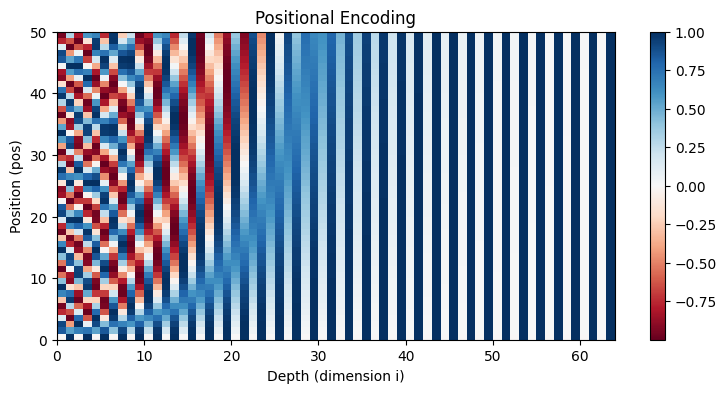

In [6]:
# 히트맵으로 시각화한다
plt.figure(figsize=(9, 4))
plt.pcolormesh(pe.numpy(), cmap='RdBu')
plt.xlabel('Depth (dimension i)')
plt.ylabel('Position (pos)')
plt.colorbar()
plt.title('Positional Encoding')
plt.show()

히트맵을 보면 왼쪽(작은 $i$)은 주기가 짧아 위치에 따라 빠르게 진동하고, 오른쪽(큰 $i$)은 주기가 길어 천천히 변한다. 이진수 표기에서 가장 낮은 자릿수는 0과 1이 빠르게 번갈아 나오고 높은 자릿수는 천천히 바뀌는 것과 같은 구조다. 각 행(=각 위치)을 가로로 읽으면 서로 다른 고유한 패턴, 즉 위치의 지문이 된다.

## 임베딩 스케일링 — $\sqrt{d_{model}}$ 을 곱하는 이유

논문에는 눈에 잘 띄지 않는 디테일이 하나 있다. 임베딩 벡터에 포지셔널 인코딩을 더하기 전에 $\sqrt{d_{model}}$ 을 곱한다는 것이다.

$$ \text{입력 표현} = \text{Embedding}(x) \times \sqrt{d_{model}} + PE $$

이유는 두 신호의 **크기 균형**에 있다. 임베딩 행렬은 보통 작은 분산(예: $N(0, 1/d_{model})$)으로 초기화하므로 각 원소의 크기가 $1/\sqrt{d_{model}}$ 수준으로 작다. 반면 포지셔널 인코딩의 원소는 $[-1, 1]$ 범위다. 그대로 더하면 위치 신호가 단어의 의미 신호를 삼켜 버린다. $\sqrt{d_{model}}$ 을 곱해 임베딩의 크기를 1 수준으로 끌어올리면 두 신호가 비슷한 스케일에서 섞인다. 아래에서 수치로 확인한다.

In [7]:
# 스케일링 전후 임베딩과 PE의 크기(표준편차) 비교
E_demo = torch.randn(100, config['d_model']) / math.sqrt(config['d_model'])  # N(0, 1/d_model) 초기화
emb_std = E_demo.std().item()
scaled_std = (E_demo * math.sqrt(config['d_model'])).std().item()
pe_std = pe.std().item()

print(f'임베딩 원소 표준편차            : {emb_std:.4f}')
print(f'√d_model 곱한 뒤 표준편차       : {scaled_std:.4f}')
print(f'포지셔널 인코딩 표준편차         : {pe_std:.4f}')

임베딩 원소 표준편차            : 0.1230
√d_model 곱한 뒤 표준편차       : 0.9839
포지셔널 인코딩 표준편차         : 0.5903


스케일링 전에는 임베딩이 PE보다 한참 작지만, $\sqrt{d_{model}}$ 을 곱하면 둘이 비슷한 크기가 되는 것을 확인할 수 있다. 이제 shape 지도의 첫 두 칸이 채워졌다.

# 3. 어텐션의 핵심 — Scaled Dot-Product Attention

## Q, K, V — 어텐션은 부드러운 검색이다

트랜스포머의 어텐션은 세 종류의 벡터를 사용한다. **쿼리(Query, Q)**, **키(Key, K)**, **밸류(Value, V)** 다. 검색 시스템에 비유하면 역할이 분명해진다.

- **Q (질의)** : 내가 지금 찾고 싶은 것. "동사 '먹었다'의 주어는 누구지?"
- **K (색인)** : 각 단어가 내건 간판. "나는 주어 후보입니다"
- **V (내용물)** : 검색이 성사됐을 때 실제로 가져올 정보.

일반 검색은 쿼리와 가장 잘 맞는 **하나의** 문서를 반환하지만, 어텐션은 **모든** 단어의 V를 "쿼리와 키가 얼마나 잘 맞는가"에 비례하는 가중치로 섞어서 가져온다. 그래서 어텐션을 **부드러운(soft) 검색**, 혹은 **가중 평균에 의한 정보 수집**이라 부를 수 있다.

수식은 다음 한 줄이다.

$$ \text{Attention}(Q, K, V) = \text{softmax}\left(\frac{QK^T}{\sqrt{d_k}}\right)V $$

이 한 줄을 세 조각으로 분해해서, 각 조각이 왜 그 모양인지 하나씩 따진다.

**조각 1 — $QK^T$ : 왜 내적으로 유사도를 재는가.** 두 벡터의 내적은 방향이 비슷할수록(가리키는 의미가 비슷할수록) 커진다. 11장에서 다룬 코사인 유사도에서 정규화를 뺀 것이 내적이다. $Q$ 가 $(S_q, d_k)$, $K$ 가 $(S_k, d_k)$ 이면 $QK^T$ 는 $(S_q, S_k)$ 행렬이 되어, **모든 쿼리-키 쌍의 유사도가 행렬 곱 한 번에** 계산된다. RNN이 $n$ 스텝에 걸쳐 하던 정보 전달을 한 번의 연산으로 끝내는 것으로, 트랜스포머 병렬성의 원천이 바로 이 행렬 곱이다.

**조각 2 — softmax : 점수를 확률로.** 유사도 점수를 그대로 가중치로 쓰면 합이 1이 아니어서 "가중 평균"이 되지 않는다. 각 쿼리 행마다 softmax를 적용해 합이 1인 확률 분포로 바꾼다. 5장에서 만든 softmax를 이번에는 직접 구현해야 하는데, 여기서 첫 번째 함정을 만난다.

## softmax 직접 구현 — 수치 안정화가 필요한 이유

softmax의 정의는 $p_i = e^{z_i} / \sum_j e^{z_j}$ 다. 정의 그대로 구현하면 어떻게 될까. `exp` 는 입력이 조금만 커져도 폭발하는 함수라서, float32가 표현할 수 있는 최댓값(약 $3.4 \times 10^{38}$)을 금방 넘어 `inf` 가 되고, `inf / inf = nan` 이 된다.

In [8]:
def softmax_naive(x, dim=-1):
    exp_x = torch.exp(x)
    return exp_x / exp_x.sum(dim=dim, keepdim=True)

z = torch.tensor([1000.0, 1001.0, 1002.0])
print('naive softmax :', softmax_naive(z))    # exp(1000)이 inf가 되어 nan 발생

naive softmax : tensor([nan, nan, nan])


해결책은 간단한 항등식이다. 분자와 분모를 $e^{m}$ ($m = \max_j z_j$)으로 동시에 나누어도 값은 변하지 않는다.

$$ p_i = \frac{e^{z_i}}{\sum_j e^{z_j}} = \frac{e^{z_i - m}}{\sum_j e^{z_j - m}} $$

최댓값을 빼면 exp의 입력이 전부 0 이하가 되므로 $e^{z_i - m} \le 1$, 오버플로가 원천 차단된다. 파이토치의 `F.softmax` 내부에도 이 트릭이 들어 있다. 우리는 밖으로 꺼내서 직접 쓴다.

In [9]:
def softmax(x, dim=-1):
    """수치 안정화(최댓값 빼기)를 적용한 softmax"""
    x_max = x.max(dim=dim, keepdim=True).values
    exp_x = torch.exp(x - x_max)
    return exp_x / exp_x.sum(dim=dim, keepdim=True)

print('안정화 softmax :', softmax(z))

# 검증: 파이토치 공식 구현과 대조
x_test = torch.randn(4, 7, 9)
print('파이토치 구현과 일치 :', torch.allclose(softmax(x_test, dim=-1),
                                        torch.nn.functional.softmax(x_test, dim=-1), atol=1e-6))

안정화 softmax : tensor([0.0900, 0.2447, 0.6652])
파이토치 구현과 일치 : True


## 조각 3 — 왜 $\sqrt{d_k}$ 로 나누는가

수식에서 가장 궁금한 부분이다. 나누지 않으면 무슨 일이 생길까.

$q$ 와 $k$ 의 각 성분이 평균 0, 분산 1인 독립 확률변수라고 하자. 내적 $q \cdot k = \sum_{i=1}^{d_k} q_i k_i$ 는 분산 1짜리 항 $d_k$ 개의 합이므로, **분산이 $d_k$, 표준편차가 $\sqrt{d_k}$** 가 된다. $d_k$ 가 커질수록 내적 값이 $\pm\sqrt{d_k}$ 수준으로 넓게 흩어진다는 뜻이다.

문제는 softmax가 큰 입력 차이에 극단적으로 반응한다는 점이다. 점수 분포가 넓으면 softmax 출력이 한 원소에 1이 쏠리는 **포화(saturation)** 상태가 되고, 포화 지점에서는 5장 시그모이드에서 본 것과 같은 **기울기 소실**이 일어나 학습이 멈춘다. 표준편차가 $\sqrt{d_k}$ 로 커졌으니 $\sqrt{d_k}$ 로 나누어 다시 1로 되돌리는 것, 이것이 "scaled"의 의미다. 실험으로 확인한다.

In [10]:
# 실험: d_k가 클 때 내적의 표준편차와 softmax 포화
d_k = 512
q = torch.randn(1000, d_k)
k = torch.randn(1000, d_k)
dots = (q * k).sum(dim=-1)

print(f'd_k = {d_k}')
print(f'내적의 표준편차 (이론값 √d_k = {math.sqrt(d_k):.1f}) : {dots.std().item():.1f}')

scores = torch.randn(1000, 10) * math.sqrt(d_k)      # 스케일링 전의 점수 분포를 흉내
before = softmax(scores, dim=-1).max(dim=-1).values.mean()
after = softmax(scores / math.sqrt(d_k), dim=-1).max(dim=-1).values.mean()
print(f'softmax 최대 확률의 평균 — 스케일링 전 : {before:.4f} (한 곳에 쏠림 = 포화)')
print(f'softmax 최대 확률의 평균 — 스케일링 후 : {after:.4f} (완만한 분포)')

d_k = 512
내적의 표준편차 (이론값 √d_k = 22.6) : 23.6
softmax 최대 확률의 평균 — 스케일링 전 : 0.9586 (한 곳에 쏠림 = 포화)
softmax 최대 확률의 평균 — 스케일링 후 : 0.3178 (완만한 분포)


스케일링 전에는 softmax가 사실상 argmax처럼 한 원소에 확률을 몰아주고(포화), 스케일링 후에는 완만한 분포가 유지되는 것을 볼 수 있다.



## 마스킹 (Masking) — 보면 안 되는 곳을 가리는 법

어텐션 점수 행렬에서 특정 위치를 계산에서 제외하고 싶을 때가 있다. 대표적으로 두 경우다.

- **패딩 마스크** : 배치를 만들 때 짧은 문장 뒤를 `<pad>` 로 채우는데, 이 가짜 토큰에는 주의를 주면 안 된다.
- **룩-어헤드 마스크** : 디코더가 다음 단어를 예측할 때 미래의 정답을 미리 보면 안 된다. (Part 7에서 자세히 다룬다)

방법은 softmax의 성질을 이용한다. **가리고 싶은 위치의 점수를 $-\infty$ 로 바꾸면**, $e^{-\infty} = 0$ 이므로 softmax를 통과한 뒤 해당 위치의 가중치가 정확히 0이 된다. 즉 마스킹은 별도의 장치가 아니라 "softmax에 들어가기 전 점수 조작"일 뿐이다.

이제 세 조각을 합쳐 스케일드 닷-프로덕트 어텐션을 완성한다. 어텐션 가중치 행렬도 함께 반환하도록 만드는데, 나중에 모델이 어디를 보고 있는지 시각화할 때 쓰기 위해서다.

In [11]:
def scaled_dot_product_attention(Q, K, V, mask=None):
    """Q : (..., S_q, d_k),  K : (..., S_k, d_k),  V : (..., S_k, d_v)
    mask : (..., S_q, S_k) 불리언 텐서. True = 주의 허용, False = 가림.
    반환 : (출력 (..., S_q, d_v), 어텐션 가중치 (..., S_q, S_k))
    """
    d_k = Q.size(-1)
    scores = torch.matmul(Q, K.transpose(-2, -1)) / math.sqrt(d_k)   # ① 유사도 / √d_k
    if mask is not None:
        neg_inf = torch.full_like(scores, float('-inf'))
        scores = torch.where(mask, scores, neg_inf)                  # ② 가릴 곳은 -inf
    attn_weights = softmax(scores, dim=-1)                           # ③ 확률 분포로
    output = torch.matmul(attn_weights, V)                           # ④ V의 가중 평균
    return output, attn_weights

아주 작은 예제로 손계산 검증을 한다. 토큰 2개, $d_k = 2$ 로 두고 각 단계를 수동으로 따라가 본다.

$$ Q = K = V = \begin{pmatrix} 1 & 0 \\ 0 & 1 \end{pmatrix}, \qquad \frac{QK^T}{\sqrt{2}} = \frac{1}{\sqrt{2}}\begin{pmatrix} 1 & 0 \\ 0 & 1 \end{pmatrix} $$

1행의 softmax는 $\left[\frac{e^{0.7071}}{e^{0.7071}+e^{0}},\; \frac{e^{0}}{e^{0.7071}+e^{0}}\right] \approx [0.6698,\; 0.3302]$ 이고, 출력 1행은 $0.6698 \times (1,0) + 0.3302 \times (0,1) = (0.6698,\; 0.3302)$ 이다.

In [12]:
# 손계산 검증
Q = K = V = torch.eye(2)
out, attn = scaled_dot_product_attention(Q, K, V)
print('어텐션 가중치 :\n', attn)
print('출력 :\n', out)

# 검증: 파이토치 공식 구현(F.scaled_dot_product_attention)과 대조
Qr, Kr, Vr = torch.randn(2, 5, 8), torch.randn(2, 6, 8), torch.randn(2, 6, 8)
ours, _ = scaled_dot_product_attention(Qr, Kr, Vr)
theirs = torch.nn.functional.scaled_dot_product_attention(Qr, Kr, Vr)
print('파이토치 구현과 일치 :', torch.allclose(ours, theirs, atol=1e-5))

어텐션 가중치 :
 tensor([[0.6698, 0.3302],
        [0.3302, 0.6698]])
출력 :
 tensor([[0.6698, 0.3302],
        [0.3302, 0.6698]])
파이토치 구현과 일치 : True


손계산 값과 정확히 일치하고, 파이토치 공식 구현과도 일치한다. shape 지도의 어텐션 칸을 채울 준비가 됐다. 다음은 이 어텐션을 여러 개로 복제하는 멀티-헤드다.

# 4. 멀티-헤드 어텐션 (Multi-Head Attention)

## 왜 어텐션을 여러 개로 쪼개는가



어텐션 한 번은 하나의 가중 평균이다. 그런데 softmax는 보통 소수의 위치에 확률을 집중시키므로, 하나의 어텐션은 사실상 **한 종류의 관계**밖에 잘 포착하지 못한다. 문제는 언어의 관계가 여러 겹이라는 점이다. "그는 사과를 먹었다"에서 '먹었다'는 주어('그는')와의 관계, 목적어('사과를')와의 관계를 **동시에** 봐야 한다.

멀티-헤드 어텐션의 해법은 $d_{model}$ 차원을 $h$ 개의 조각(**헤드**)으로 나누고, 각 헤드가 $d_k = d_{model}/h$ 차원의 **서로 다른 부분공간**에서 독립적으로 어텐션을 수행하게 하는 것이다. 각 헤드는 서로 다른 $W^Q, W^K, W^V$ 를 통해 입력을 서로 다른 관점으로 사영하므로, 어떤 헤드는 주어-동사 관계를, 어떤 헤드는 수식 관계를 보도록 분화할 수 있다. 마지막에 모든 헤드의 결과를 이어 붙이고(concat) 출력 사영 $W^O$ 로 다시 섞는다.

$$ \text{MultiHead}(Q,K,V) = \text{Concat}(head_1, \dots, head_h)\, W^O, \qquad head_i = \text{Attention}(QW_i^Q,\; KW_i^K,\; VW_i^V) $$

> **공짜 점심** : 헤드를 나눠도 총 연산량은 거의 같다. 각 헤드의 차원이 $d_k = d_{model}/h$ 로 줄어들기 때문에, $h$ 개 헤드의 연산량 합은 $d_{model}$ 차원 어텐션 한 번과 같다. 같은 비용으로 $h$ 가지 관점을 얻는 셈이다.



## 부품 준비 — linear 함수



Q, K, V 사영에는 선형 변환이 필요하다. 규칙대로 `nn.Linear` 대신 직접 만든다. 3장에서 배운 가설식 $XW + b$ 그 자체이고, 파라미터 초기화는 **Xavier 초기화**(6장)를 수식대로 구현한다. $U(-a, a),\; a = \sqrt{6/(fan_{in}+fan_{out})}$ 로 초기화하면 층을 지나도 신호의 분산이 유지된다.

In [13]:
def linear(x, W, b):
    """선형 변환 : x (..., in_f) @ W (in_f, out_f) + b (out_f,)"""
    return torch.matmul(x, W) + b

def init_linear(fan_in, fan_out):
    """Xavier 균등 초기화된 가중치/편향 딕셔너리를 만든다"""
    a = math.sqrt(6.0 / (fan_in + fan_out))
    W = (torch.rand(fan_in, fan_out) * 2 - 1) * a
    return {'W': W.requires_grad_(), 'b': torch.zeros(fan_out, requires_grad=True)}

## shape 트릭 — 헤드를 반복문 없이 병렬 처리하기



헤드마다 for문을 돌리면 병렬성이 죽는다. 실전 구현의 트릭은 다음과 같다. 헤드별 사영 행렬 $W_i^Q$ 를 따로 두는 대신 **$d_{model} \times d_{model}$ 사영 하나로 전부 계산한 뒤 텐서를 재배열**하는 것이다. 큰 사영 행렬을 세로로 $h$ 등분하면 각 조각이 헤드별 사영과 같으므로 수학적으로 동일하다. 재배열 과정을 shape로 추적하면 다음과 같다.

| 단계 | 연산 | shape |
|:---|:---|:---:|
| 사영 | `linear(x, W_q, b_q)` | $(B, S, d_{model})$ |
| 헤드 분리 | `view(B, S, h, d_k)` | $(B, S, h, d_k)$ |
| 축 교환 | `transpose(1, 2)` | $(B, h, S, d_k)$ |
| 어텐션 | Part 3의 함수 그대로 | $(B, h, S, d_k)$ |
| 축 복원 | `transpose(1, 2)` | $(B, S, h, d_k)$ |
| 헤드 결합 | `view(B, S, d_model)` | $(B, S, d_{model})$ |

축 교환으로 $h$ 를 배치 차원처럼 앞으로 빼는 것이 핵심이다. Part 3의 `scaled_dot_product_attention` 은 마지막 두 축만 사용하도록 만들어 두었으므로($(..., S, d_k)$), $(B, h, S, d_k)$ 를 넣으면 **$B \times h$ 개의 어텐션이 한 번에** 계산된다. 마지막의 `transpose + view` 조합이 곧 Concat에 해당한다.

> **주의** : `transpose` 직후의 텐서는 메모리상 연속이 아니므로 `view` 를 바로 쓸 수 없다. `contiguous()` 를 호출해 메모리를 재배열한 뒤 `view` 해야 한다.

In [14]:
def multi_head_attention(x_q, x_kv, p, num_heads, mask=None):
    """멀티-헤드 어텐션.
    x_q : (B, S_q, d_model) 쿼리를 만들 입력
    x_kv : (B, S_k, d_model) 키/밸류를 만들 입력 (셀프 어텐션이면 x_q와 동일)
    p : {'q','k','v','o'} 각각 {'W','b'} 를 담은 파라미터 딕셔너리
    반환 : (출력 (B, S_q, d_model), 어텐션 가중치 (B, h, S_q, S_k))
    """
    B, S_q, d_model = x_q.shape
    d_k = d_model // num_heads

    Q = linear(x_q, p['q']['W'], p['q']['b'])      # (B, S_q, d_model)
    K = linear(x_kv, p['k']['W'], p['k']['b'])     # (B, S_k, d_model)
    V = linear(x_kv, p['v']['W'], p['v']['b'])     # (B, S_k, d_model)

    def split_heads(t):                            # (B, S, d_model) → (B, h, S, d_k)
        B_, S_, _ = t.shape
        return t.view(B_, S_, num_heads, d_k).transpose(1, 2)

    Qh, Kh, Vh = split_heads(Q), split_heads(K), split_heads(V)

    out, attn_weights = scaled_dot_product_attention(Qh, Kh, Vh, mask)   # (B, h, S_q, d_k)

    out = out.transpose(1, 2).contiguous().view(B, S_q, d_model)         # Concat
    return linear(out, p['o']['W'], p['o']['b']), attn_weights

def init_mha(d_model):
    return {'q': init_linear(d_model, d_model), 'k': init_linear(d_model, d_model),
            'v': init_linear(d_model, d_model), 'o': init_linear(d_model, d_model)}

검증한다. 이번 상대는 `nn.MultiheadAttention` 이다. 우리 파라미터를 파이토치 모듈에 복사해 넣고 같은 입력에 대한 출력을 비교한다. 파이토치는 가중치를 $(out, in)$ 모양으로 저장하고 $xW^T$ 로 곱하므로, 우리의 $W$($xW$ 방식)를 **전치해서** 넣어야 같은 연산이 된다.

In [15]:
# 검증: nn.MultiheadAttention에 우리 가중치를 이식해 대조
import torch.nn as nn   # 검증(채점)용으로만 사용한다

d_model, num_heads = config['d_model'], config['num_heads']
p_test = init_mha(d_model)
x = torch.randn(2, 5, d_model)

mha_torch = nn.MultiheadAttention(d_model, num_heads, batch_first=True)
with torch.no_grad():
    mha_torch.in_proj_weight.copy_(torch.cat([p_test['q']['W'].t(),
                                              p_test['k']['W'].t(),
                                              p_test['v']['W'].t()], dim=0))
    mha_torch.in_proj_bias.copy_(torch.cat([p_test['q']['b'], p_test['k']['b'], p_test['v']['b']]))
    mha_torch.out_proj.weight.copy_(p_test['o']['W'].t())
    mha_torch.out_proj.bias.copy_(p_test['o']['b'])

ours, _ = multi_head_attention(x, x, p_test, num_heads)
theirs, _ = mha_torch(x, x, x)
print('출력 shape 유지 :', ours.shape == x.shape)
print('파이토치 구현과 일치 :', torch.allclose(ours, theirs, atol=1e-5))

출력 shape 유지 : True
파이토치 구현과 일치 : True


파라미터 수도 확인한다. 멀티-헤드 어텐션 하나의 파라미터는 $d_{model} \times d_{model}$ 사영 4개(Q, K, V, O)와 편향 4개이므로 $4(d_{model}^2 + d_{model})$ 이다.

In [16]:
n_params = sum(t.numel() for proj in p_test.values() for t in proj.values())
print(f'멀티-헤드 어텐션 파라미터 수 : {n_params}')
print(f'이론값 4(d_model² + d_model) : {4 * (d_model**2 + d_model)}')

멀티-헤드 어텐션 파라미터 수 : 16640
이론값 4(d_model² + d_model) : 16640


# 5. 나머지 부품 — FFN, 잔차 연결, 층 정규화, 드롭아웃



## Position-wise Feed-Forward Network



어텐션 다음에는 항상 **FFN** 이 붙는다. 두 개의 선형 변환 사이에 ReLU를 끼운 단순한 구조다.

$$ \text{FFN}(x) = \max(0,\; xW_1 + b_1)\, W_2 + b_2 $$

**왜 어텐션만으로 부족한가?** 어텐션의 출력은 결국 V 벡터들의 **가중 평균**, 즉 선형 결합이다. 어텐션이 하는 일이 "단어들 사이에서 정보를 **섞는** 것"이라면, 각 단어가 모아 온 정보를 **비선형으로 가공(변환)**하는 단계가 따로 필요하다. 그 역할이 FFN이다. 어텐션 = 섞기(mix), FFN = 변환(transform)으로 역할이 분담된다.

**"Position-wise"의 의미**는 같은 FFN이 시퀀스의 **모든 위치에 독립적으로, 동일하게** 적용된다는 것이다. 위치 간 정보 교환은 이미 어텐션이 끝냈으므로, FFN은 각 위치를 따로따로 처리해도 된다. 중간 차원 $d_{ff}$ 를 $d_{model}$ 보다 크게(논문은 4배) 잡는 것은, 일단 넓은 공간에 펼쳐서 가공한 뒤 다시 줄이는 병목 반대 구조로 표현력을 확보하기 위해서다.

ReLU도 규칙대로 직접 만든다. $\max(0, x)$ 그대로다.

In [17]:
def relu(x):
    """ReLU : 음수를 0으로 자른다"""
    return torch.maximum(x, torch.zeros_like(x))

def feed_forward(x, p):
    """FFN(x) = relu(x W1 + b1) W2 + b2  —  (B, S, d_model) → (B, S, d_model)"""
    hidden = relu(linear(x, p['fc1']['W'], p['fc1']['b']))    # (B, S, d_ff) 로 확장
    return linear(hidden, p['fc2']['W'], p['fc2']['b'])       # 다시 (B, S, d_model)

def init_ffn(d_model, d_ff):
    return {'fc1': init_linear(d_model, d_ff), 'fc2': init_linear(d_ff, d_model)}

## 잔차 연결 (Residual Connection)



트랜스포머의 모든 서브층(어텐션, FFN)은 출력에 **입력을 그대로 더한다**.

$$ x \leftarrow x + \text{Sublayer}(x) $$

이유는 6장에서 다룬 기울기 소실과 직결된다. 층을 깊게 쌓으면 역전파 시 기울기가 층마다 곱해지며 소실될 수 있는데, $x + \text{Sublayer}(x)$ 를 $x$ 로 미분하면 $1 + \text{Sublayer}'(x)$ 가 되어 **항상 1이 더해진 채로** 기울기가 흘러간다. 덧셈 경로가 기울기의 고속도로 역할을 하는 것이다. 또한 각 서브층은 "출력 전체"가 아니라 "입력 대비 바꿀 양(잔차)"만 학습하면 되므로 학습이 쉬워진다.

여기서 Part 1의 설계 원칙이 다시 등장한다. $x$ 와 $\text{Sublayer}(x)$ 를 **더하려면 두 shape가 같아야 한다**. 모든 서브층의 입출력 차원이 $d_{model}$ 로 고정된 진짜 이유가 바로 잔차 연결이다.



## 층 정규화 (Layer Normalization)

잔차 덧셈 뒤에는 **층 정규화**를 적용한다. 각 위치의 벡터를 **그 벡터 자신의 평균과 분산**으로 정규화한 뒤, 학습 가능한 $\gamma$(스케일)와 $\beta$(이동)로 되돌릴 여지를 준다.

$$ \text{LayerNorm}(x) = \gamma \odot \frac{x - \mu}{\sqrt{\sigma^2 + \epsilon}} + \beta $$

깊은 네트워크에서는 층을 지날수록 값의 분포가 이리저리 표류하는데, 층마다 분포를 리셋해 주면 학습이 안정된다. $\epsilon$ 은 분산이 0일 때 0으로 나누는 것을 막는 작은 수다.

> **왜 BatchNorm이 아닌가** : 배치 정규화는 **배치 방향**으로 통계를 내므로, 문장마다 길이가 다르고 패딩이 섞이는 NLP에서는 통계가 불안정하다(같은 "3번째 단어" 자리라도 문장마다 전혀 다른 단어가 온다). 층 정규화는 **각 단어 벡터 내부**($d_{model}$ 방향)에서 통계를 내므로 배치 크기·문장 길이와 무관하게 동작한다.

수식 그대로 구현하고 `nn.LayerNorm` 과 대조한다.

In [18]:
def layer_norm(x, gamma, beta, eps=1e-5):
    """마지막 차원(d_model 방향)에 대한 층 정규화"""
    mean = x.mean(dim=-1, keepdim=True)
    var = x.var(dim=-1, keepdim=True, unbiased=False)   # 모분산 (N으로 나눔)
    x_norm = (x - mean) / torch.sqrt(var + eps)
    return gamma * x_norm + beta

def init_layer_norm(d_model):
    return {'gamma': torch.ones(d_model, requires_grad=True),
            'beta': torch.zeros(d_model, requires_grad=True)}

In [19]:
# 검증: nn.LayerNorm과 대조
x = torch.randn(2, 5, config['d_model'])
ln_p = init_layer_norm(config['d_model'])
ln_torch = nn.LayerNorm(config['d_model'])

ours = layer_norm(x, ln_p['gamma'], ln_p['beta'])
theirs = ln_torch(x)
print('파이토치 구현과 일치 :', torch.allclose(ours, theirs, atol=1e-5))

파이토치 구현과 일치 : True


## 드롭아웃 (Dropout)



과적합을 막기 위해 학습 중에 뉴런을 확률 $p$ 로 무작위로 끈다(6장 참고). 트랜스포머에서는 각 서브층의 출력(잔차에 더해지기 직전)과 임베딩+포지셔널 인코딩 직후에 적용한다.

직접 구현할 때의 핵심은 **inverted dropout** 스케일링이다. 학습 때 살아남은 값들을 $1/(1-p)$ 로 키워 두면 출력의 기댓값이 드롭아웃이 없을 때와 같아지므로, 추론 때는 아무 것도 하지 않아도 된다. `training` 플래그로 학습/추론을 구분한다.

In [20]:
def dropout(x, p, training):
    """inverted dropout : 학습 시 확률 p로 끄고, 살아남은 값은 1/(1-p)배"""
    if not training or p == 0.0:
        return x
    keep = (torch.rand_like(x) > p).float()
    return x * keep / (1.0 - p)

In [21]:
# 확인: 드롭아웃 후에도 평균(기댓값)이 유지되는지, 추론 모드에서는 항등인지
x = torch.ones(100000)
dropped = dropout(x, p=0.1, training=True)
print(f'학습 모드 — 0이 된 비율 : {(dropped == 0).float().mean():.4f} (p=0.1 근처)')
print(f'학습 모드 — 평균 유지   : {dropped.mean():.4f} (원본 평균 1.0 근처)')
print('추론 모드 — 항등 함수  :', torch.equal(dropout(x, 0.1, training=False), x))

학습 모드 — 0이 된 비율 : 0.0998 (p=0.1 근처)
학습 모드 — 평균 유지   : 1.0002 (원본 평균 1.0 근처)
추론 모드 — 항등 함수  : True


# 6. 인코더 조립



부품이 모두 준비됐다. 인코더 층 하나는 서브층 2개를 **Add & Norm**(잔차 연결 + 층 정규화)으로 감싼 구조다.

1. **멀티-헤드 셀프 어텐션** : Q, K, V가 전부 같은 입력에서 나온다. 문장 내의 모든 단어가 서로를 참조하며 문맥을 수집한다.
2. **FFN** : 수집한 정보를 각 위치에서 비선형 가공한다.

각 서브층은 다음 패턴을 따른다. 논문(Post-LN) 방식이다.

$$ x \leftarrow \text{LayerNorm}\big(x + \text{Dropout}(\text{Sublayer}(x))\big) $$

인코더 층의 파라미터는 딕셔너리 하나로 묶어 관리한다. `nn.Module` 이 자동으로 해 주던 파라미터 관리를 우리는 딕셔너리로 직접 한다.

In [22]:
def encoder_layer(x, p, num_heads, drop_p, training, mask=None):
    """인코더 층 하나 : (B, S, d_model) → (B, S, d_model)"""
    # 서브층 1 : 멀티-헤드 셀프 어텐션 + Add & Norm
    attn_out, _ = multi_head_attention(x, x, p['mha'], num_heads, mask)
    x = layer_norm(x + dropout(attn_out, drop_p, training),
                   p['ln1']['gamma'], p['ln1']['beta'])
    # 서브층 2 : FFN + Add & Norm
    ffn_out = feed_forward(x, p['ffn'])
    x = layer_norm(x + dropout(ffn_out, drop_p, training),
                   p['ln2']['gamma'], p['ln2']['beta'])
    return x

def init_encoder_layer(d_model, d_ff):
    return {'mha': init_mha(d_model), 'ffn': init_ffn(d_model, d_ff),
            'ln1': init_layer_norm(d_model), 'ln2': init_layer_norm(d_model)}

층을 $N$ 개 쌓으면 인코더 전체가 된다. 앞 층의 출력이 그대로 뒤 층의 입력이 되는 구조는, 모든 층의 입출력 shape가 $(B, S, d_{model})$ 로 같기 때문에 성립한다. 더미 입력으로 shape 불변을 확인한다.

In [23]:
def encoder(x, layers_p, num_heads, drop_p, training, mask=None):
    """인코더 층 N개를 순서대로 통과"""
    for p in layers_p:
        x = encoder_layer(x, p, num_heads, drop_p, training, mask)
    return x

In [24]:
# shape 불변 확인
enc_p = [init_encoder_layer(config['d_model'], config['d_ff']) for _ in range(config['num_layers'])]
dummy = torch.randn(2, 7, config['d_model'])
out = encoder(dummy, enc_p, config['num_heads'], config['dropout'], training=False)
print(f'인코더 입력 : {tuple(dummy.shape)} → 출력 : {tuple(out.shape)}  (불변)')

인코더 입력 : (2, 7, 64) → 출력 : (2, 7, 64)  (불변)


# 7. 디코더 조립



디코더 층은 서브층이 **3개**다. 인코더와 무엇이 다른지가 트랜스포머 이해의 마지막 고비다.

1. **마스크드 멀티-헤드 셀프 어텐션** : 디코더 입력(지금까지 생성된 타깃 문장)끼리의 셀프 어텐션. 단, **미래를 가린다**.
2. **크로스 어텐션 (인코더-디코더 어텐션)** : **Q는 디코더에서, K와 V는 인코더 출력에서** 온다. 번역할 때 소스 문장의 어느 단어를 참고할지 결정하는 곳으로, Seq2Seq의 어텐션과 정확히 같은 아이디어다. Part 4에서 `multi_head_attention(x_q, x_kv, ...)` 로 쿼리용 입력과 키/밸류용 입력을 분리해 둔 것이 여기서 쓰인다.
3. **FFN** : 인코더와 동일.


## 룩-어헤드 마스크 — 왜 미래를 가려야 하는가



학습 시 디코더는 정답 문장 전체를 **한꺼번에** 입력받는다(teacher forcing, Part 9에서 상세히). RNN 디코더는 어차피 순서대로 처리하므로 미래를 볼 수 없었지만, 셀프 어텐션은 기본적으로 **모든 위치가 모든 위치를 본다**. 그대로 두면 "i ate an apple"의 2번째 단어를 예측할 때 정답인 'ate'를 컨닝하게 되고, 모델은 입력을 한 칸 복사하는 무의미한 규칙만 배운다.

그래서 위치 $i$ 의 쿼리는 위치 $j \le i$ 의 키만 보도록 어텐션 점수 행렬의 **위쪽 삼각형을 가린다**. 마스크는 하삼각 행렬(`torch.tril`)로 만들면 되고, 가리는 원리는 Part 3에서 만든 그대로($-\infty$ → softmax 후 0)다.

패딩 마스크도 함께 만든다. 마스크의 shape는 어텐션 점수 $(B, h, S_q, S_k)$ 에 브로드캐스팅되도록 설계한다.

In [25]:
def make_pad_mask(seq, pad_id):
    """패딩 마스크 : (B, S) → (B, 1, 1, S).  True = 실제 토큰(주의 허용)
    쿼리가 어느 위치든(1), 어느 헤드든(1) <pad> 키는 보지 못하게 한다."""
    return (seq != pad_id).view(seq.size(0), 1, 1, seq.size(1))

def make_look_ahead_mask(seq, pad_id):
    """룩-어헤드 + 패딩 결합 마스크 : (B, S) → (B, 1, S, S)"""
    S = seq.size(1)
    tril = torch.tril(torch.ones(S, S, dtype=torch.bool))   # (S, S) 하삼각 = 과거만 True
    return make_pad_mask(seq, pad_id) & tril                 # 브로드캐스팅으로 결합

In [26]:
# 길이 4 시퀀스(마지막 1개는 패딩)의 결합 마스크 확인
demo = torch.tensor([[5, 6, 7, 0]])          # 0 = <pad>
print(make_look_ahead_mask(demo, pad_id=0)[0, 0].int())

tensor([[1, 0, 0, 0],
        [1, 1, 0, 0],
        [1, 1, 1, 0],
        [1, 1, 1, 0]], dtype=torch.int32)


행 $i$(쿼리)가 열 $j$(키)를 볼 수 있으면 1이다. 대각선 위(미래)와 마지막 열(패딩)이 0으로 가려진 것을 확인할 수 있다. 이제 디코더 층을 조립한다. 크로스 어텐션의 가중치는 나중에 시각화할 수 있도록 밖으로 전달할 통로(`attn_store`)를 열어 둔다.

In [27]:
def decoder_layer(x, enc_out, p, num_heads, drop_p, training,
                  self_mask=None, cross_mask=None, attn_store=None):
    """디코더 층 하나 : x (B, T, d_model), enc_out (B, S, d_model) → (B, T, d_model)"""
    # 서브층 1 : 마스크드 셀프 어텐션 (미래 차단)
    attn_out, _ = multi_head_attention(x, x, p['self_mha'], num_heads, self_mask)
    x = layer_norm(x + dropout(attn_out, drop_p, training),
                   p['ln1']['gamma'], p['ln1']['beta'])
    # 서브층 2 : 크로스 어텐션 — Q는 디코더(x), K·V는 인코더 출력(enc_out)
    attn_out, cross_attn = multi_head_attention(x, enc_out, p['cross_mha'], num_heads, cross_mask)
    if attn_store is not None:
        attn_store.append(cross_attn.detach())
    x = layer_norm(x + dropout(attn_out, drop_p, training),
                   p['ln2']['gamma'], p['ln2']['beta'])
    # 서브층 3 : FFN
    ffn_out = feed_forward(x, p['ffn'])
    x = layer_norm(x + dropout(ffn_out, drop_p, training),
                   p['ln3']['gamma'], p['ln3']['beta'])
    return x

def init_decoder_layer(d_model, d_ff):
    return {'self_mha': init_mha(d_model), 'cross_mha': init_mha(d_model),
            'ffn': init_ffn(d_model, d_ff), 'ln1': init_layer_norm(d_model),
            'ln2': init_layer_norm(d_model), 'ln3': init_layer_norm(d_model)}

def decoder(x, enc_out, layers_p, num_heads, drop_p, training,
            self_mask=None, cross_mask=None, attn_store=None):
    for p in layers_p:
        x = decoder_layer(x, enc_out, p, num_heads, drop_p, training,
                          self_mask, cross_mask, attn_store)
    return x

크로스 어텐션의 마스크에 대해 한 가지 짚고 넘어간다. 크로스 어텐션에서 쿼리는 타깃 위치, 키는 **소스** 위치다. 소스 문장은 이미 완성되어 있는 "볼 수 있는 과거"이므로 룩-어헤드 마스크가 필요 없고, 소스의 패딩만 가리면 된다. 즉 크로스 어텐션의 마스크는 소스의 패딩 마스크 $(B, 1, 1, S)$ 를 그대로 쓴다.

# 8. 트랜스포머 완성



## 출력층, 그리고 softmax의 행방



디코더의 출력 $(B, T, d_{model})$ 을 단어 예측으로 바꾸려면 타깃 단어 집합 크기로 사영하는 선형 층 하나가 필요하다. 결과인 $(B, T, vocab)$ 의 각 벡터를 **로짓(logit)**이라 부른다. 각 위치에서 "다음 단어"에 대한 점수 벡터다.

여기서 5장부터 반복해 온 원칙을 떠올리자.

> **주의** : 모델의 출력에는 softmax를 적용하지 않는다. 5장에서 `nn.CrossEntropyLoss` 가 softmax를 **포함**하므로 가설에 softmax를 쓰지 않는다고 배웠다. 이번에는 그 손실 함수마저 직접 만들 것이므로(Part 9), softmax가 손실 계산 **안에서** 어떻게 처리되는지 이번에야말로 눈으로 보게 된다.



## 전체 조립



임베딩부터 출력층까지 모든 파라미터를 하나의 딕셔너리에 담고, 전체 순전파를 하나의 함수로 조립한다. 임베딩 행렬은 $N(0, 1/d_{model})$ 로 초기화한다(Part 2에서 $\sqrt{d_{model}}$ 스케일링과 균형을 맞추기로 한 그 초기화다).

In [28]:
def init_transformer(src_vocab, tgt_vocab, config, max_len=50):
    """트랜스포머 전체 파라미터를 담은 딕셔너리를 만든다"""
    d_model, d_ff, N = config['d_model'], config['d_ff'], config['num_layers']
    return {
        'src_emb': (torch.randn(src_vocab, d_model) / math.sqrt(d_model)).requires_grad_(),
        'tgt_emb': (torch.randn(tgt_vocab, d_model) / math.sqrt(d_model)).requires_grad_(),
        'pe': positional_encoding(max_len, d_model),            # 고정값 (학습 안 함)
        'enc_layers': [init_encoder_layer(d_model, d_ff) for _ in range(N)],
        'dec_layers': [init_decoder_layer(d_model, d_ff) for _ in range(N)],
        'out': init_linear(d_model, tgt_vocab),
    }

def transformer_forward(src, tgt_in, params, config, pad_id, training, attn_store=None):
    """src : (B, S) 소스 문장,  tgt_in : (B, T) 디코더 입력 → 로짓 (B, T, tgt_vocab)"""
    d_model, h, drop_p = config['d_model'], config['num_heads'], config['dropout']

    # 마스크 준비
    src_mask = make_pad_mask(src, pad_id)             # (B, 1, 1, S)  인코더 셀프 + 크로스 공용
    tgt_mask = make_look_ahead_mask(tgt_in, pad_id)   # (B, 1, T, T)  디코더 셀프

    # 인코더 : 임베딩 × √d_model + PE → 드롭아웃 → 층 스택
    x = embedding(src, params['src_emb']) * math.sqrt(d_model) + params['pe'][:src.size(1)]
    x = dropout(x, drop_p, training)
    enc_out = encoder(x, params['enc_layers'], h, drop_p, training, src_mask)

    # 디코더 : 동일한 입력 처리 → 층 스택 (크로스 어텐션은 enc_out 참조)
    y = embedding(tgt_in, params['tgt_emb']) * math.sqrt(d_model) + params['pe'][:tgt_in.size(1)]
    y = dropout(y, drop_p, training)
    dec_out = decoder(y, enc_out, params['dec_layers'], h, drop_p, training,
                      self_mask=tgt_mask, cross_mask=src_mask, attn_store=attn_store)

    # 출력층 : (B, T, d_model) → (B, T, tgt_vocab) 로짓. softmax는 손실 함수 몫.
    return linear(dec_out, params['out']['W'], params['out']['b'])

더미 데이터로 전체 순전파의 shape를 검증하고, 파라미터 수를 센다. 파라미터가 딕셔너리와 리스트에 중첩되어 있으므로, 재귀적으로 텐서 잎(leaf)만 모으는 함수를 만든다. `nn.Module` 의 `parameters()` 가 하던 일이다.

In [29]:
def collect_params(obj, out=None):
    """중첩된 dict/list에서 requires_grad=True 텐서만 재귀적으로 수집"""
    if out is None:
        out = []
    if isinstance(obj, torch.Tensor):
        if obj.requires_grad:
            out.append(obj)
    elif isinstance(obj, dict):
        for v in obj.values():
            collect_params(v, out)
    elif isinstance(obj, (list, tuple)):
        for v in obj:
            collect_params(v, out)
    return out

In [30]:
# 더미 순전파 shape 검증 + 파라미터 수
dummy_params = init_transformer(src_vocab=15, tgt_vocab=19, config=config)
src_d = torch.randint(3, 15, (2, 4))          # (B=2, S=4)
tgt_d = torch.randint(3, 19, (2, 5))          # (B=2, T=5)
logits = transformer_forward(src_d, tgt_d, dummy_params, config, pad_id=0, training=False)

print(f'src {tuple(src_d.shape)} + tgt {tuple(tgt_d.shape)} → 로짓 {tuple(logits.shape)}')
n_total = sum(t.numel() for t in collect_params(dummy_params))
print(f'학습 가능한 파라미터 수 : {n_total:,}')

src (2, 4) + tgt (2, 5) → 로짓 (2, 5, 19)
학습 가능한 파라미터 수 : 170,835


로짓의 shape가 $(B, T, tgt\_vocab)$ 으로 나오면 조립 성공이다. Part 1의 shape 지도가 전부 채워졌다. 이제 이 모델이 실제로 학습되는지 확인할 차례다.

# 9. 학습 — 미니 한→영 번역



## 데이터셋 준비



외부 다운로드 없이 노트북 안에서 완결되는 **미니 병렬 코퍼스**를 만든다. 주어 4개 × 목적어 5개 × 동사 5개를 의미가 자연스러운 조합으로 묶어 한국어-영어 문장 쌍 60개를 생성한다. 규모는 장난감이지만 과제 자체는 진짜다. 한국어는 **주어-목적어-동사(SOV)**, 영어는 **주어-동사-목적어(SVO)** 어순이므로 모델은 단어 대응뿐 아니라 **어순 재배열**을 배워야 하고, '사과를 → an apple'처럼 한 단어가 두 단어로 갈라지는 **관사 규칙**도 배워야 한다.

> **일반화 테스트 설계** : 60개 중 6개 조합을 학습에서 제외해 테스트용으로 남긴다. 테스트 문장의 단어들은 전부 학습 데이터에 (다른 조합으로) 등장하지만, **그 조합 자체는 처음 보는 문장**이다. 모델이 문장을 통째로 암기했는지, 조합 규칙을 배웠는지 구분하는 장치다.

> **실제 데이터로 바꾸려면** : 이 toy 코퍼스 대신 AI Hub 한-영 병렬 코퍼스 등을 받아 같은 형식의 (한국어 토큰 리스트, 영어 토큰 리스트) 쌍으로 만들면 이후 코드는 그대로 동작한다. 실전에서는 단어 수준 토큰화 대신 15장에서 다룬 서브워드 토큰화(BPE)를 쓴다.

In [31]:
# 미니 병렬 코퍼스 : 주어 × (동사별로 자연스러운 목적어) 조합
subjects = {'나는': 'i', '너는': 'you', '그는': 'he', '그녀는': 'she'}
objects  = {'사과를': ['an', 'apple'], '책을': ['a', 'book'],
            '물을': ['water'], '커피를': ['coffee'], '빵을': ['bread']}
verbs    = {'먹었다': 'ate', '읽었다': 'read', '마셨다': 'drank',
            '샀다': 'bought', '좋아했다': 'liked'}
plausible = {'먹었다': ['사과를', '빵을'], '읽었다': ['책을'], '마셨다': ['물을', '커피를'],
             '샀다': list(objects), '좋아했다': list(objects)}

pairs = []
for v, obj_list in plausible.items():
    for o in obj_list:
        for s in subjects:
            ko = [s, o, v]                                  # SOV
            en = [subjects[s], verbs[v]] + objects[o]       # SVO
            pairs.append((ko, en))

print(f'전체 문장 쌍 : {len(pairs)}개')
print('예시 :', pairs[0][0], '→', pairs[0][1])

전체 문장 쌍 : 60개
예시 : ['나는', '사과를', '먹었다'] → ['i', 'ate', 'an', 'apple']


## 단어 집합과 특수 토큰



한국어(소스)와 영어(타깃)의 단어 집합을 각각 만든다. 특수 토큰 3개의 역할을 분명히 하고 간다.

- `<pad>` (0) : 배치 안에서 문장 길이를 맞추기 위한 빈칸. 마스크로 가려지고 손실에서도 제외된다.
- `<sos>` (1) : 디코더에게 "생성을 시작하라"고 알리는 신호. 타깃(영어) 쪽에만 필요하다.
- `<eos>` (2) : 문장의 끝. 소스에는 "여기까지가 입력"임을, 디코더에게는 "이것을 예측하면 생성을 멈춘다"는 것을 가르친다.

In [32]:
PAD, SOS, EOS = 0, 1, 2

ko_vocab = ['<pad>', '<sos>', '<eos>'] + sorted({w for ko, _ in pairs for w in ko})
en_vocab = ['<pad>', '<sos>', '<eos>'] + sorted({w for _, en in pairs for w in en})
ko2id = {w: i for i, w in enumerate(ko_vocab)}
en2id = {w: i for i, w in enumerate(en_vocab)}

print(f'한국어 단어 집합 ({len(ko_vocab)}개) : {ko_vocab}')
print(f'영어 단어 집합 ({len(en_vocab)}개) : {en_vocab}')

한국어 단어 집합 (17개) : ['<pad>', '<sos>', '<eos>', '그녀는', '그는', '나는', '너는', '마셨다', '먹었다', '물을', '빵을', '사과를', '샀다', '읽었다', '좋아했다', '책을', '커피를']
영어 단어 집합 (19개) : ['<pad>', '<sos>', '<eos>', 'a', 'an', 'apple', 'ate', 'book', 'bought', 'bread', 'coffee', 'drank', 'he', 'i', 'liked', 'read', 'she', 'water', 'you']


## Teacher Forcing — 디코더의 입력과 정답 만들기



학습 시 디코더에는 무엇을 넣고, 무엇을 맞히게 할까. 정답 문장을 **한 칸 어긋나게 두 벌** 만든다.

| | | | | | |
|:---|:---:|:---:|:---:|:---:|:---:|
| 디코더 입력 | `<sos>` | i | ate | an | apple |
| 예측할 정답 | i | ate | an | apple | `<eos>` |

위치 $t$ 의 디코더 입력까지 보고 위치 $t$ 의 정답(즉 **다음 단어**)을 맞히는 구조다. 이렇게 정답을 입력으로 밀어 넣어 주는 방식을 **teacher forcing**이라 한다. 모델이 앞 단어를 틀려도 다음 예측은 정답 문맥에서 출발하므로 학습이 안정되고, 무엇보다 룩-어헤드 마스크 덕분에 **모든 위치의 예측을 병렬로 한 번에** 학습할 수 있다. RNN 디코더가 한 스텝씩 하던 일을 행렬 곱 한 번으로 끝내는 것, 이것이 Part 0에서 말한 트랜스포머 병렬성의 완성이다.

소스는 `단어들 + <eos>`, 디코더 입력은 `<sos> + 단어들`, 정답은 `단어들 + <eos>` 로 인코딩하고 최대 길이까지 `<pad>` 를 채운다.

In [33]:
def encode(tokens, w2id, max_len, prepend_sos=False, append_eos=False):
    ids = ([SOS] if prepend_sos else []) + [w2id[t] for t in tokens] + ([EOS] if append_eos else [])
    return ids + [PAD] * (max_len - len(ids))

SRC_LEN = 4                                   # 한국어 3단어 + <eos>
TGT_LEN = 5                                   # 영어 최대 4단어 + <sos> 또는 <eos>

# 일반화 테스트용으로 남길 6개 조합 (단어는 전부 학습에 등장, 조합만 새것)
test_combos = [('그는', '사과를', '먹었다'), ('나는', '커피를', '마셨다'),
               ('그녀는', '책을', '샀다'), ('너는', '빵을', '좋아했다'),
               ('나는', '책을', '읽었다'), ('그녀는', '물을', '샀다')]
train_pairs = [(ko, en) for ko, en in pairs if tuple(ko) not in test_combos]
test_pairs  = [(ko, en) for ko, en in pairs if tuple(ko) in test_combos]

def to_tensors(pair_list):
    src    = torch.tensor([encode(ko, ko2id, SRC_LEN, append_eos=True) for ko, _ in pair_list])
    tgt_in = torch.tensor([encode(en, en2id, TGT_LEN, prepend_sos=True) for _, en in pair_list])
    tgt_out = torch.tensor([encode(en, en2id, TGT_LEN, append_eos=True) for _, en in pair_list])
    return src, tgt_in, tgt_out

src_train, tgt_in_train, tgt_out_train = to_tensors(train_pairs)
print(f'학습 {len(train_pairs)}쌍 / 테스트(미학습 조합) {len(test_pairs)}쌍')
print('src    :', src_train[0].tolist(), '→', [ko_vocab[i] for i in src_train[0]])
print('tgt_in :', tgt_in_train[0].tolist(), '→', [en_vocab[i] for i in tgt_in_train[0]])
print('tgt_out:', tgt_out_train[0].tolist(), '→', [en_vocab[i] for i in tgt_out_train[0]])

학습 54쌍 / 테스트(미학습 조합) 6쌍
src    : [5, 11, 8, 2] → ['나는', '사과를', '먹었다', '<eos>']
tgt_in : [1, 13, 6, 4, 5] → ['<sos>', 'i', 'ate', 'an', 'apple']
tgt_out: [13, 6, 4, 5, 2] → ['i', 'ate', 'an', 'apple', '<eos>']


## 크로스 엔트로피 손실 직접 구현 — log-sum-exp 트릭



마지막 부품이다. 5장에서 크로스 엔트로피의 수식 $-\log(p_{정답})$ 을 배웠고, `nn.CrossEntropyLoss` 가 softmax를 포함한다는 사실을 원칙처럼 외웠다. 이번에는 그 안을 직접 연다. 로짓 $z$ 에서 정답 클래스 $c$ 의 손실은 softmax와 log를 합치면 다음처럼 정리된다.

$$ -\log p_c = -\log \frac{e^{z_c}}{\sum_j e^{z_j}} = \log\sum_j e^{z_j} - z_c $$

즉 크로스 엔트로피는 **"log-sum-exp에서 정답 로짓을 뺀 것"**이다. softmax를 명시적으로 계산할 필요조차 없다. 남은 문제는 $\log\sum_j e^{z_j}$ 의 오버플로인데, 해법은 softmax 때와 똑같이 최댓값 $m$ 을 빼는 것이다.

$$ \log\sum_j e^{z_j} = m + \log\sum_j e^{z_j - m} $$

이것이 **log-sum-exp 트릭**이고, `nn.CrossEntropyLoss` 가 별도의 softmax 없이도 안정적으로 동작하는 진짜 이유다. "손실 함수가 softmax를 포함한다"는 말의 실체가 이 항등식이다. 추가로 `<pad>` 위치는 맞힐 이유가 없으므로 손실 평균에서 제외한다(`ignore_index`가 하던 일).

In [34]:
def cross_entropy(logits, targets, pad_id):
    """logits : (N, vocab), targets : (N,).  <pad> 위치는 제외하고 평균."""
    m = logits.max(dim=-1, keepdim=True).values
    log_sum_exp = m.squeeze(-1) + torch.log(torch.exp(logits - m).sum(dim=-1))
    true_logit = logits.gather(1, targets.unsqueeze(1)).squeeze(1)   # 정답 클래스의 로짓
    nll = log_sum_exp - true_logit                                   # 샘플별 -log p_정답

    not_pad = (targets != pad_id).float()
    return (nll * not_pad).sum() / not_pad.sum()

In [35]:
# 검증: F.cross_entropy(ignore_index)와 대조
logits_t = torch.randn(30, len(en_vocab))
targets_t = torch.randint(0, len(en_vocab), (30,))
ours = cross_entropy(logits_t, targets_t, PAD)
theirs = torch.nn.functional.cross_entropy(logits_t, targets_t, ignore_index=PAD)
print('파이토치 구현과 일치 :', torch.allclose(ours, theirs, atol=1e-6))

파이토치 구현과 일치 : True


## 학습 루프



모든 부품이 검증을 통과했으니 조립품 전체를 학습시킨다. 파라미터를 초기화하고 `collect_params` 로 잎 텐서들을 모아 Adam 옵티마이저에 등록한다. 데이터가 54쌍뿐이므로 미니 배치 없이 **풀 배치**로 학습한다. 루프의 구조는 3장부터 반복해 온 그대로다 — 순전파 → 손실 → `zero_grad` → `backward`(autograd의 몫) → `step`.

In [36]:
torch.manual_seed(0)
params = init_transformer(len(ko_vocab), len(en_vocab), config)
optimizer = torch.optim.Adam(collect_params(params), lr=0.001)

nb_epochs = 400
loss_history = []
for epoch in range(1, nb_epochs + 1):
    logits = transformer_forward(src_train, tgt_in_train, params, config,
                                 pad_id=PAD, training=True)
    loss = cross_entropy(logits.reshape(-1, len(en_vocab)),
                         tgt_out_train.reshape(-1), pad_id=PAD)

    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

    loss_history.append(loss.item())
    if epoch % 50 == 0:
        print('Epoch {:4d}/{} Cost: {:.6f}'.format(epoch, nb_epochs, loss.item()))

Epoch   50/400 Cost: 0.090928
Epoch  100/400 Cost: 0.018853
Epoch  150/400 Cost: 0.007923
Epoch  200/400 Cost: 0.004466
Epoch  250/400 Cost: 0.003884
Epoch  300/400 Cost: 0.002670
Epoch  350/400 Cost: 0.001844
Epoch  400/400 Cost: 0.001487


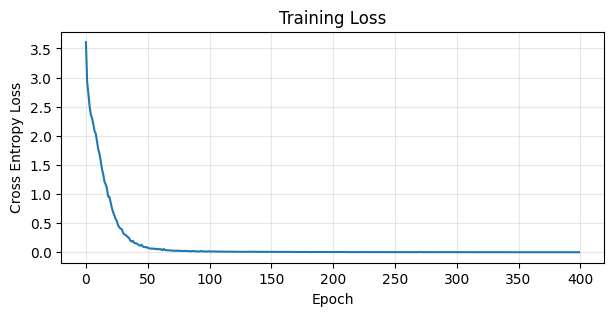

In [37]:
plt.figure(figsize=(7, 3))
plt.plot(loss_history)
plt.xlabel('Epoch')
plt.ylabel('Cross Entropy Loss')
plt.title('Training Loss')
plt.grid(True, alpha=0.3)
plt.show()

손실이 0 근처까지 떨어지면 학습 데이터는 완전히 소화한 것이다. 하지만 진짜 시험은 **학습에 없던 조합**을 번역할 수 있는가다.

# 10. 추론과 시각화



## 그리디 디코딩 — 추론은 왜 순차적인가



학습 때는 teacher forcing 덕분에 모든 위치를 병렬로 처리했지만, 추론 때는 정답 문장이 없다. 디코더에 넣어 줄 입력을 **모델 스스로 만들어야** 하므로, 어쩔 수 없이 한 단어씩 순차적으로 생성한다.

1. 디코더 입력을 `<sos>` 하나로 시작한다.
2. 순전파 후 **마지막 위치의 로짓**에서 가장 확률 높은 단어를 고른다(argmax — 그래서 그리디).
3. 고른 단어를 디코더 입력 뒤에 붙이고 2로 돌아간다. `<eos>` 가 나오면 멈춘다.

로짓에 softmax를 씌우지 않고 바로 argmax를 하는 것에 주목하자. softmax는 단조 증가 함수라 **순위를 바꾸지 않으므로**, 확률값 자체가 필요 없는 그리디 선택에서는 생략해도 결과가 같다.

> **빔 서치(Beam Search)** : 그리디는 매 스텝 1등만 선택하므로 초반의 아까운 2등이 이후 더 좋은 문장으로 이어질 가능성을 버린다. 상위 $k$ 개 후보를 유지하며 탐색하는 빔 서치가 실전 번역기의 표준이지만, 여기서는 그리디로 충분하다.

In [38]:
def translate(ko_tokens, params, config, max_len=TGT_LEN, attn_store=None):
    """한국어 토큰 리스트 → 영어 토큰 리스트 (그리디 디코딩)"""
    src = torch.tensor([encode(ko_tokens, ko2id, SRC_LEN, append_eos=True)])
    dec_ids = [SOS]
    for _ in range(max_len):
        tgt_in = torch.tensor([dec_ids])
        if attn_store is not None:
            attn_store.clear()                     # 마지막 스텝의 어텐션만 남긴다
        logits = transformer_forward(src, tgt_in, params, config,
                                     pad_id=PAD, training=False, attn_store=attn_store)
        next_id = logits[0, -1].argmax().item()    # 마지막 위치의 로짓에서 argmax
        if next_id == EOS:
            break
        dec_ids.append(next_id)
    return [en_vocab[i] for i in dec_ids[1:]]

In [39]:
# 평가 : 학습 문장 재현 + 미학습 조합 일반화
def evaluate(pair_list, name):
    correct = 0
    for ko, en in pair_list:
        pred = translate(ko, params, config)
        correct += (pred == en)
    print(f'{name} 정확도 : {correct}/{len(pair_list)}')

evaluate(train_pairs, '학습 데이터')
evaluate(test_pairs, '미학습 조합')

print()
for ko, en in test_pairs[:3]:
    print(f"{' '.join(ko):18s} → 예측: {' '.join(translate(ko, params, config)):16s} (정답: {' '.join(en)})")

학습 데이터 정확도 : 54/54
미학습 조합 정확도 : 6/6

그는 사과를 먹었다         → 예측: he ate an apple  (정답: he ate an apple)
나는 책을 읽었다          → 예측: i read a book    (정답: i read a book)
나는 커피를 마셨다         → 예측: i drank coffee   (정답: i drank coffee)


학습에 한 번도 등장하지 않은 조합을 번역해 낸다면, 모델이 문장을 암기한 것이 아니라 **주어·목적어·동사의 역할과 SOV→SVO 재배열 규칙을 조합 가능한 형태로** 배웠다는 뜻이다. 단어 수준 암기로는 불가능한 일이다.


## 크로스 어텐션 시각화 — 모델은 어디를 보는가



Part 7에서 열어 둔 통로(`attn_store`)로 크로스 어텐션 가중치를 꺼내 히트맵으로 그린다. 크로스 어텐션은 "영어 단어를 생성하는 순간 한국어의 어느 단어를 참고하는가"이므로, 잘 학습됐다면 **단어 정렬(alignment)** 이 보여야 한다. 예컨대 'ate'를 만들 때는 '먹었다'를, 'apple'을 만들 때는 '사과를'을 강하게 봐야 한다.

한글 축 레이블을 위해 폰트 설정이 필요하다. Colab에는 한글 폰트가 없어 그대로 그리면 □□로 깨진다.

In [40]:
!pip install -q koreanize-matplotlib
import koreanize_matplotlib   # matplotlib 한글 폰트 자동 설정

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.9/7.9 MB 68.7 MB/s eta 0:00:00


그는 사과를 먹었다 → he ate an apple


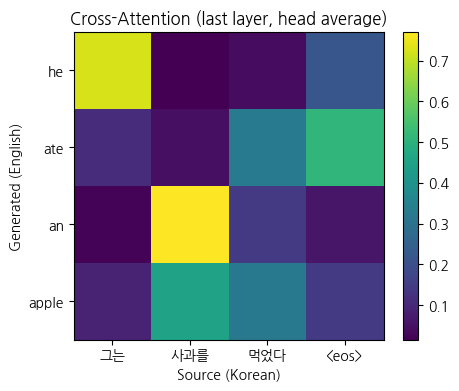

In [41]:
# 미학습 조합 하나를 번역하며 마지막 디코딩 스텝의 크로스 어텐션을 수집
sample_ko = list(test_pairs[0][0])
attn_store = []
pred = translate(sample_ko, params, config, attn_store=attn_store)
print(' '.join(sample_ko), '→', ' '.join(pred))

# attn_store 에는 디코더 층 수만큼 쌓인다. 마지막 층, 헤드 평균을 그린다.
attn = attn_store[-1][0].mean(dim=0)                 # (T, S) : 타깃 위치 × 소스 위치
src_labels = sample_ko + ['<eos>']
tgt_labels = pred

plt.figure(figsize=(5, 4))
plt.imshow(attn[:len(tgt_labels), :len(src_labels)], cmap='viridis', aspect='auto')
plt.xticks(range(len(src_labels)), src_labels)
plt.yticks(range(len(tgt_labels)), tgt_labels)
plt.xlabel('Source (Korean)')
plt.ylabel('Generated (English)')
plt.title('Cross-Attention (last layer, head average)')
plt.colorbar()
plt.show()

행이 생성된 영어 단어, 열이 한국어 소스 단어이고 밝을수록 강하게 주목한 것이다. 동사를 만들 때 동사를, 목적어를 만들 때 목적어를 바라보는 대각선이 아닌 **꼬인 정렬**이 보인다면 — SOV와 SVO의 어순 차이 때문에 정렬선이 교차하는 것 — 모델이 진짜로 어순 재배열을 수행하고 있다는 시각적 증거다. 우리가 만든 것은 규칙 기반 번역기가 아니라, 데이터에서 스스로 정렬을 발견한 모델이다.

# 11. 정리



## 부품 요약

이 노트북에서 만든 모든 부품과, 각 부품이 존재하는 이유를 한 표로 정리한다.

| 부품 | 하는 일 | 왜 이 구조인가 |
|:---|:---|:---|
| 임베딩 × $\sqrt{d_{model}}$ | 단어 → 밀집 벡터 | 스케일링으로 PE와 크기 균형을 맞춘다 |
| 포지셔널 인코딩 | 순서 정보 주입 | RNN 제거로 잃은 순서를 sin/cos 지문으로 되찾는다 |
| Scaled Dot-Product | 유사도 기반 가중 평균 | 행렬 곱 1번 = 전 단어쌍 연결(병렬성), $\sqrt{d_k}$ 나눗셈으로 softmax 포화 방지 |
| 마스킹 | 특정 위치 차단 | $-\infty$ → softmax 후 가중치 0. 패딩·미래 차단에 공용 |
| 멀티-헤드 | 어텐션 $h$ 개 병렬 | 서로 다른 부분공간에서 여러 관계를 동시에 포착, 총 연산량은 동일 |
| FFN | 위치별 비선형 변환 | 어텐션은 섞기(선형 결합)만 하므로 변환 담당이 필요 |
| 잔차 연결 | $x + \text{Sublayer}(x)$ | 기울기 고속도로. $d_{model}$ 이 불변인 이유 |
| 층 정규화 | 벡터 내부 정규화 | 분포 표류 방지. 가변 길이 시퀀스라 BatchNorm 대신 사용 |
| 룩-어헤드 마스크 | 미래 차단 | teacher forcing 병렬 학습과 "컨닝 방지"의 양립 |
| 크로스 어텐션 | Q=디코더, K·V=인코더 | Seq2Seq 어텐션의 재현 — 소스의 어디를 볼지 결정 |
| log-sum-exp 손실 | $\log\sum e^{z_j} - z_c$ | "CrossEntropyLoss가 softmax를 포함한다"의 실체 |



## 원 논문 대비 단순화한 것들

이 구현은 구조적으로는 원 논문과 같지만, 학습 규모가 작아 생략한 장치들이 있다. 실전 구현을 읽을 때 마주칠 이름들이므로 목록으로 남긴다.

- **학습률 워밍업 스케줄** : 논문은 학습 초반 학습률을 서서히 올렸다가 낮추는 스케줄을 쓴다. 큰 모델의 초기 불안정을 막는 장치다.
- **라벨 스무딩(Label Smoothing)** : 정답에 확률 1.0 대신 0.9를 주고 나머지를 분산시켜 과신을 막는다.
- **임베딩-출력층 가중치 공유** : 타깃 임베딩 행렬과 출력층 가중치를 공유해 파라미터를 절약한다.
- **서브워드 토큰화(BPE)** : 단어 수준 대신 15장의 서브워드 단위를 쓴다.
- **빔 서치** : 그리디 대신 상위 $k$ 개 후보를 유지하며 디코딩한다.
- **Pre-LN** : 층 정규화를 서브층 앞으로 옮긴 변형(Pre-LN)이 요즘은 더 일반적이다. 깊은 스택에서 학습이 더 안정적이기 때문이다.



## 트랜스포머 이후 — BERT와 GPT로

트랜스포머를 부품까지 이해했다면 이후의 모델들은 재배치 문제가 된다.

- **BERT** = 트랜스포머의 **인코더만** 쌓은 모델. 룩-어헤드 마스크가 없으므로 문장 전체를 양방향으로 보며, 빈칸 맞히기(masked LM)로 사전 학습한다. 문장 이해 과제에 강하다.
- **GPT** = 트랜스포머의 **디코더만** 쌓은 모델(크로스 어텐션은 제거). 룩-어헤드 마스크를 유지한 채 다음 단어 예측만으로 사전 학습한다. 문장 생성에 강하다.

우리가 이번에 만든 마스크드 셀프 어텐션, FFN, 잔차 연결, 층 정규화가 그대로 GPT의 전부이고, 마스크를 뺀 버전이 BERT의 전부다. without magic으로 열어 본 상자 안에, 이후 배울 모든 모델의 부품이 이미 다 들어 있었던 셈이다.